<a href="https://colab.research.google.com/github/emanaak04-svg/medical-xai/blob/main/07_gradcam.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Transparent Medical Image Classification via Explainable AI
## Phase 3 — Gradient-weighted Class Activation Mapping (Grad-CAM)


**Objective:** Grad-CAM produces a localisation heatmap highlighting the regions of an input image that most influenced the model's prediction. Unlike black-box outputs, Grad-CAM makes the model's decision spatially interpretable — a radiologist can verify whether the model is attending to clinically relevant anatomical regions or learning spurious correlations.

**Author:** Eman Ayman Ahmed Abukhousa  
**Program:** BSc Data Science & Artificial Intelligence, IITG — Year 3

## 01. Rebuild Model & Load Checkpoint
The trained ResNet-50 checkpoint saved during Day 5 training is loaded here. The model must be set to eval() mode before Grad-CAM hooks are registered — this disables dropout and switches batch normalisation to inference mode.

In [1]:
import torch
import torch.nn as nn
import torchvision.models as models
import torchvision.transforms as transforms
import numpy as np
import matplotlib.pyplot as plt
import os
from PIL import Image

from google.colab import drive
drive.mount('/content/drive')

try:
    import cv2
except ImportError:
    import subprocess
    subprocess.run(['pip', 'install', 'opencv-python-headless'], check=True)
    import cv2

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'

model = models.resnet50(weights=None)
model.fc = nn.Sequential(
    nn.Dropout(p=0.5),
    nn.Linear(model.fc.in_features, 256),
    nn.ReLU(),
    nn.Dropout(p=0.3),
    nn.Linear(256, 1)
)

checkpoint_path = '/content/drive/MyDrive/medical-xai/best_model.pth'
model.load_state_dict(torch.load(checkpoint_path, map_location=device))
model = model.to(device)
model.eval()

print(f"Compute device : {device}")
print("Checkpoint loaded — model in eval mode.")

Mounted at /content/drive
Compute device : cuda
Checkpoint loaded — model in eval mode.


## 02. Grad-CAM Implementation
Grad-CAM works by extracting the gradients of the model's output with respect to the final convolutional layer — layer4[2].conv3 in ResNet-50. These gradients are globally average-pooled to produce per-channel importance weights. A weighted sum of the activation maps, passed through ReLU, produces the localisation heatmap. ReLU is applied because we are only interested in features that positively influence the prediction.

Forward and backward hooks are registered on the target layer to capture
activations and gradients without modifying the model architecture.

In [2]:
class GradCAM:
    """Grad-CAM for binary classifier with single sigmoid output."""

    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None
        self._register_hooks()

    def _register_hooks(self):
        def forward_hook(module, input, output):
            self.activations = output.detach()

        def backward_hook(module, grad_in, grad_out):
            self.gradients = grad_out[0].detach()

        self.target_layer.register_forward_hook(forward_hook)
        self.target_layer.register_full_backward_hook(backward_hook)

    def generate(self, input_tensor):
        input_tensor = input_tensor.to(device).requires_grad_(True)
        output = self.model(input_tensor)
        prob = torch.sigmoid(output).item()

        self.model.zero_grad()
        output.backward()

        weights = self.gradients.mean(dim=(2, 3), keepdim=True)
        cam = (weights * self.activations).sum(dim=1, keepdim=True)
        cam = torch.relu(cam)

        cam = cam.squeeze().cpu().numpy()
        cam = cam - cam.min()
        if cam.max() > 0:
            cam = cam / cam.max()

        return cam, prob


gradcam = GradCAM(model, model.layer4[2].conv3)
print("Grad-CAM hooks registered on layer4[2].conv3")

Grad-CAM hooks registered on layer4[2].conv3


## 03. Preprocessing & Overlay Helpers
Two helper functions are defined here. The first loads an image from disk and returns both a PIL version for display and a normalised tensor for inference — using the same normalization parameters applied during training. The second blends the Grad-CAM heatmap onto the original X-ray using OpenCV's JET colormap, where red indicates high activation and blue indicates low activation.

In [3]:
val_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5330, 0.5330, 0.5330],
                         std=[0.0349, 0.0349, 0.0349]),
])

def load_image(path):
    img_pil = Image.open(path).convert('RGB').resize((224, 224))
    tensor = val_transforms(img_pil).unsqueeze(0)
    return img_pil, tensor

def overlay_heatmap(img_pil, cam, alpha=0.45):
    cam_uint8 = np.uint8(255 * cam)
    heatmap = cv2.applyColorMap(
        cv2.resize(cam_uint8, (224, 224)),
        cv2.COLORMAP_JET
    )
    heatmap_rgb = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)
    img_np = np.array(img_pil)
    overlay = np.uint8(alpha * heatmap_rgb + (1 - alpha) * img_np)
    return Image.fromarray(overlay)

print("Helpers defined.")

Helpers defined.


## 04. Single Image Visualisation

One NORMAL and one PNEUMONIA image are selected from the test set. Grad-CAM
is run on each and the result is displayed as three panels side by side —
the original X-ray, the raw heatmap, and the overlay. The prediction
probability and true label are shown in the title.

**Note on misclassification:** The NORMAL case is predicted as PNEUMONIA
with p=1.000. The heatmap reveals the model is attending to the lower
lung and abdominal region — not a clinically relevant area for pneumonia
diagnosis. This is a documented failure case and will be analysed in the
Results section as evidence of spatial bias in the model's attention mechanism.

In [4]:
import os
from google.colab import userdata

os.makedirs('/root/.kaggle', exist_ok=True)
with open('/root/.kaggle/kaggle.json', 'w') as f:
    f.write(f'{{"username":"emanaymanabukhousa","key":"{userdata.get("KAGGLE_KEY")}"}}\n')
os.chmod('/root/.kaggle/kaggle.json', 0o600)

!pip install -q kaggle
!kaggle datasets download -d paultimothymooney/chest-xray-pneumonia \
    -p /content/images --unzip

print("Done.")
!ls /content/images/chest_xray/

Dataset URL: https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia
License(s): other
100% 2.29G/2.29G [00:57<00:00, 43.0MB/s]

Done.
chest_xray  __MACOSX  test  train  val


/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:865: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at /pytorch/aten/src/ATen/cuda/CublasHandlePool.cpp:330.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


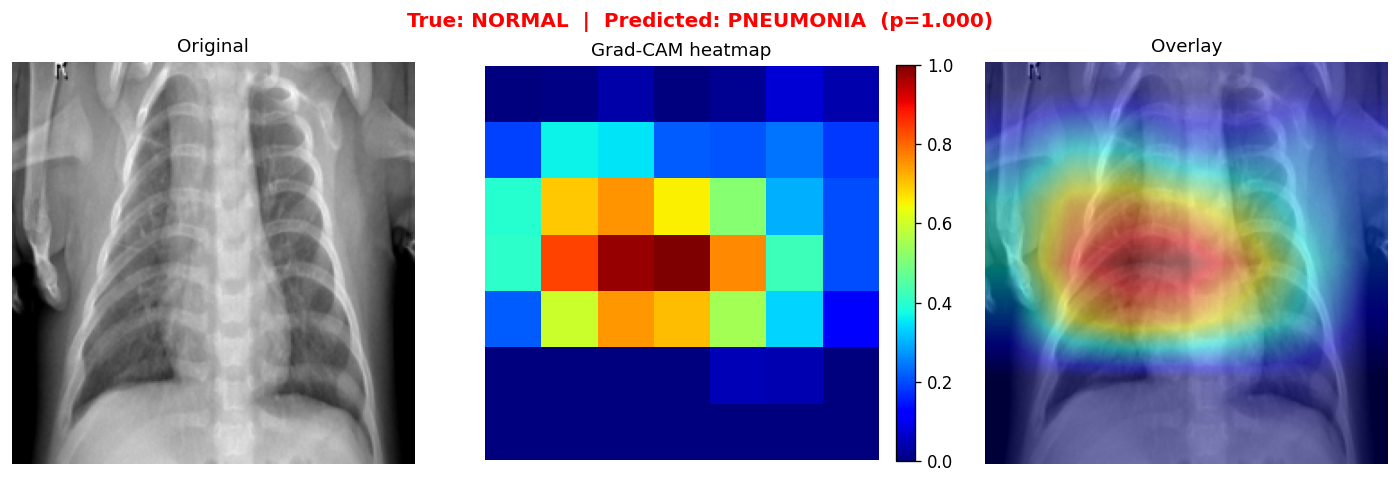

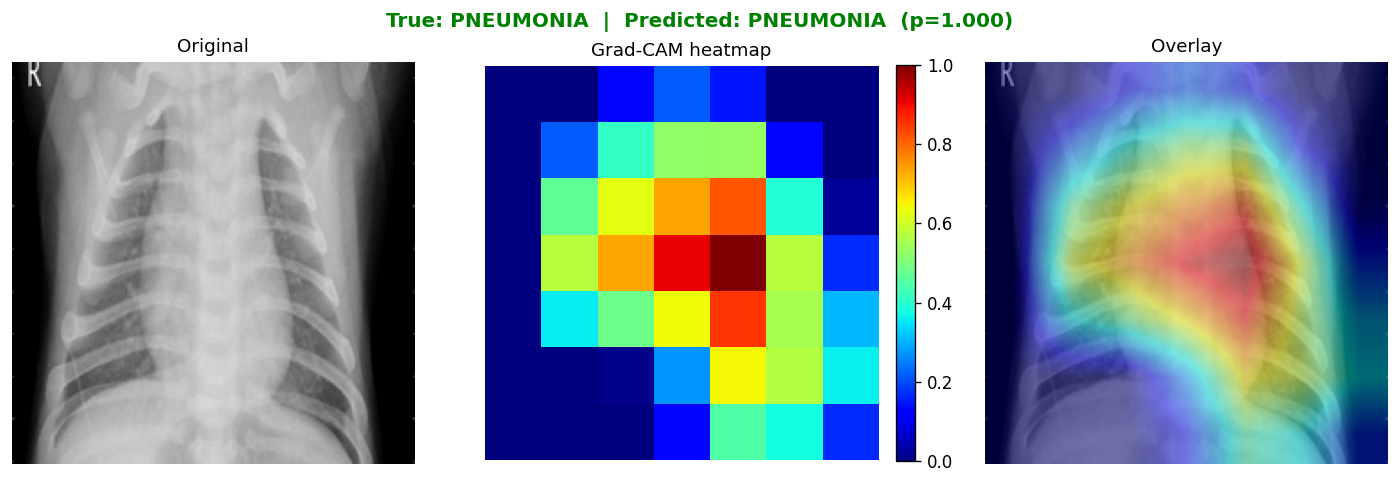

In [5]:
data_dir = '/content/images/chest_xray/test'

normal_img_path = os.path.join(
    data_dir, 'NORMAL',
    os.listdir(os.path.join(data_dir, 'NORMAL'))[0]
)
pneumo_img_path = os.path.join(
    data_dir, 'PNEUMONIA',
    os.listdir(os.path.join(data_dir, 'PNEUMONIA'))[0]
)

def plot_gradcam_row(img_path, true_label):
    img_pil, tensor = load_image(img_path)
    cam, prob = gradcam.generate(tensor)
    overlay = overlay_heatmap(img_pil, cam)
    pred_label = "PNEUMONIA" if prob >= 0.5 else "NORMAL"

    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    axes[0].imshow(img_pil, cmap='gray')
    axes[0].set_title('Original', fontsize=11)
    axes[0].axis('off')

    hm = axes[1].imshow(cam, cmap='jet', vmin=0, vmax=1)
    axes[1].set_title('Grad-CAM heatmap', fontsize=11)
    axes[1].axis('off')
    plt.colorbar(hm, ax=axes[1], fraction=0.046, pad=0.04)

    axes[2].imshow(overlay)
    axes[2].set_title('Overlay', fontsize=11)
    axes[2].axis('off')

    colour = 'green' if pred_label == true_label else 'red'
    fig.suptitle(
        f'True: {true_label}  |  Predicted: {pred_label}  (p={prob:.3f})',
        fontsize=12, fontweight='bold', color=colour
    )
    plt.tight_layout()
    plt.savefig(
        f'/content/drive/MyDrive/medical-xai/gradcam_{true_label.lower()}.png',
        dpi=150, bbox_inches='tight'
    )
    plt.show()

plot_gradcam_row(normal_img_path, 'NORMAL')
plot_gradcam_row(pneumo_img_path, 'PNEUMONIA')

## 05. Grad-CAM on False Negatives (Missed Pneumonia)
Day 6 identified 3 false negatives — pneumonia cases the model failed to detect. Visualising Grad-CAM on these is clinically important: it reveals where the model was attending instead of the affected lung regions, helping explain why the prediction failed.

False negatives found: 3


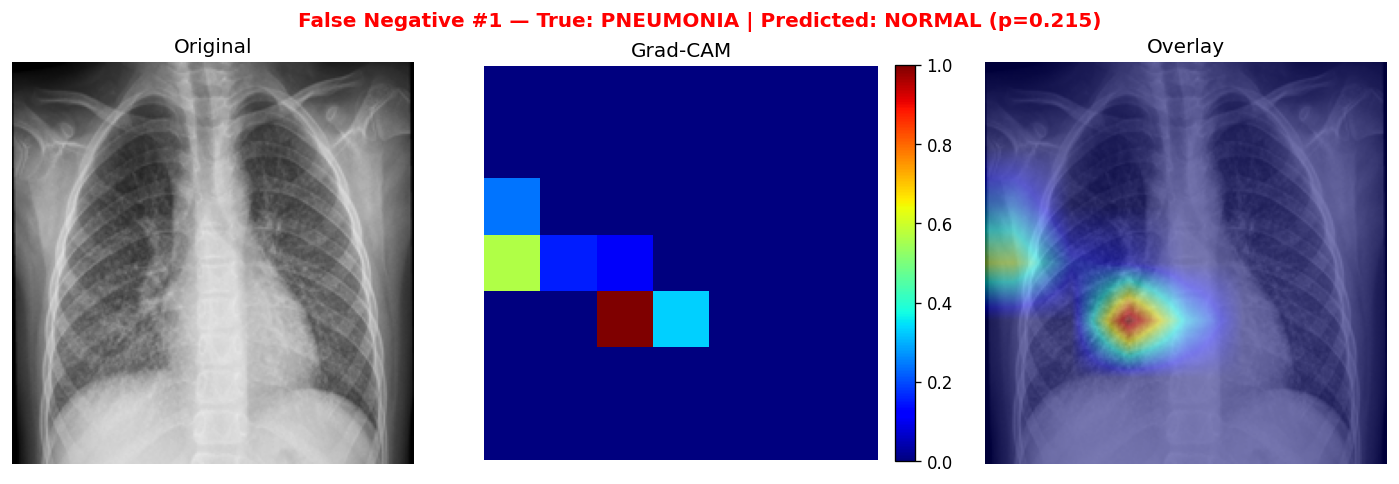

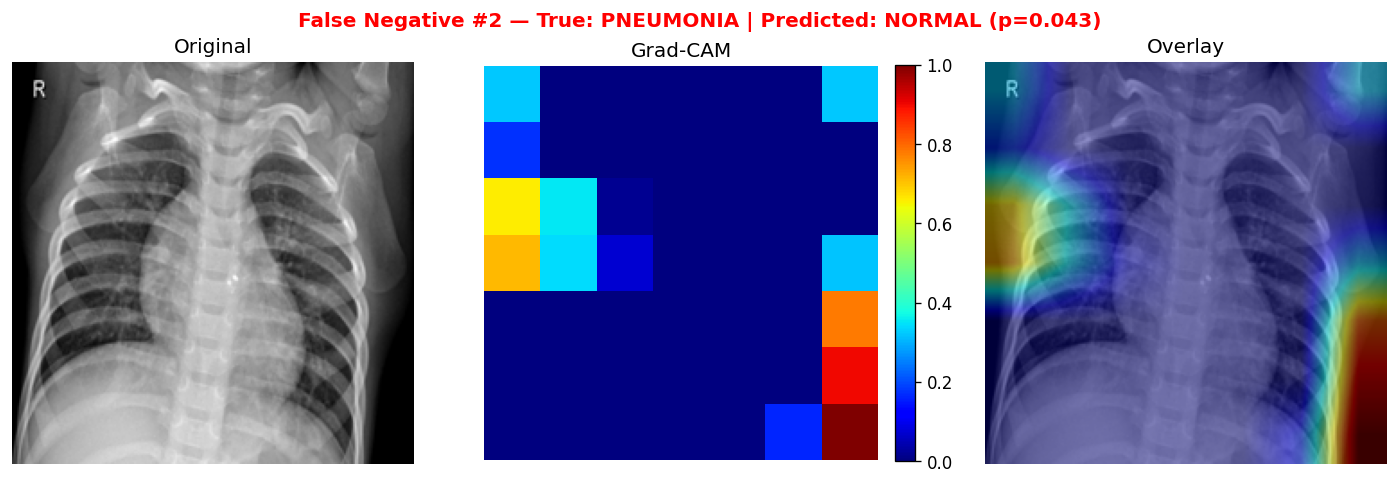

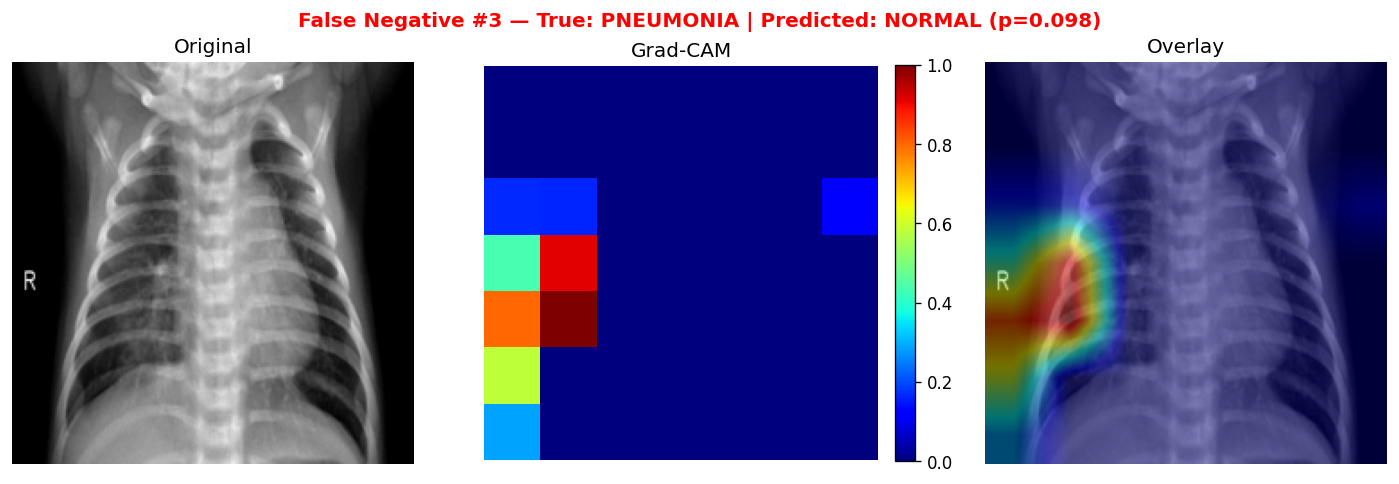

In [6]:
import pandas as pd

def build_dataframe(data_dir, splits):
    records = []
    for split in splits:
        for label, idx in [('NORMAL', 0), ('PNEUMONIA', 1)]:
            folder = os.path.join(data_dir, split, label)
            for fname in os.listdir(folder):
                if fname.endswith(('.jpeg', '.jpg', '.png')):
                    records.append({
                        'filepath': os.path.join(folder, fname),
                        'label': idx
                    })
    return pd.DataFrame(records)

test_df = build_dataframe('/content/images/chest_xray', ['test'])

all_probs, all_labels, all_paths = [], [], []

with torch.no_grad():
    for _, row in test_df.iterrows():
        img_pil = Image.open(row['filepath']).convert('RGB')
        tensor = val_transforms(img_pil).unsqueeze(0).to(device)
        prob = torch.sigmoid(model(tensor)).item()
        all_probs.append(prob)
        all_labels.append(row['label'])
        all_paths.append(row['filepath'])

import numpy as np
all_probs = np.array(all_probs)
all_labels = np.array(all_labels)

fn_mask = (all_labels == 1) & (all_probs < 0.5)
fn_paths = [p for p, m in zip(all_paths, fn_mask) if m]
fn_probs = all_probs[fn_mask]

print(f"False negatives found: {len(fn_paths)}")

for i, (path, prob) in enumerate(zip(fn_paths, fn_probs)):
    img_pil, tensor = load_image(path)
    cam, _ = gradcam.generate(tensor)
    overlay = overlay_heatmap(img_pil, cam)

    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    axes[0].imshow(img_pil, cmap='gray'); axes[0].axis('off')
    axes[0].set_title('Original')
    hm = axes[1].imshow(cam, cmap='jet'); axes[1].axis('off')
    axes[1].set_title('Grad-CAM')
    plt.colorbar(hm, ax=axes[1], fraction=0.046, pad=0.04)
    axes[2].imshow(overlay); axes[2].axis('off')
    axes[2].set_title('Overlay')
    fig.suptitle(
        f'False Negative #{i+1} — True: PNEUMONIA | Predicted: NORMAL (p={prob:.3f})',
        fontsize=12, fontweight='bold', color='red'
    )
    plt.tight_layout()
    plt.savefig(
        f'/content/drive/MyDrive/medical-xai/fn_gradcam_{i+1}.png',
        dpi=150, bbox_inches='tight'
    )
    plt.show()

## 06. Batch Visualisation — 4 Random Samples per Class
To get a broader view of how the model attends to different chest X-rays, Grad-CAM is run on 4 randomly selected NORMAL and 4 PNEUMONIA images from the test set. This gives a representative picture of the model's spatial attention patterns across both classes.

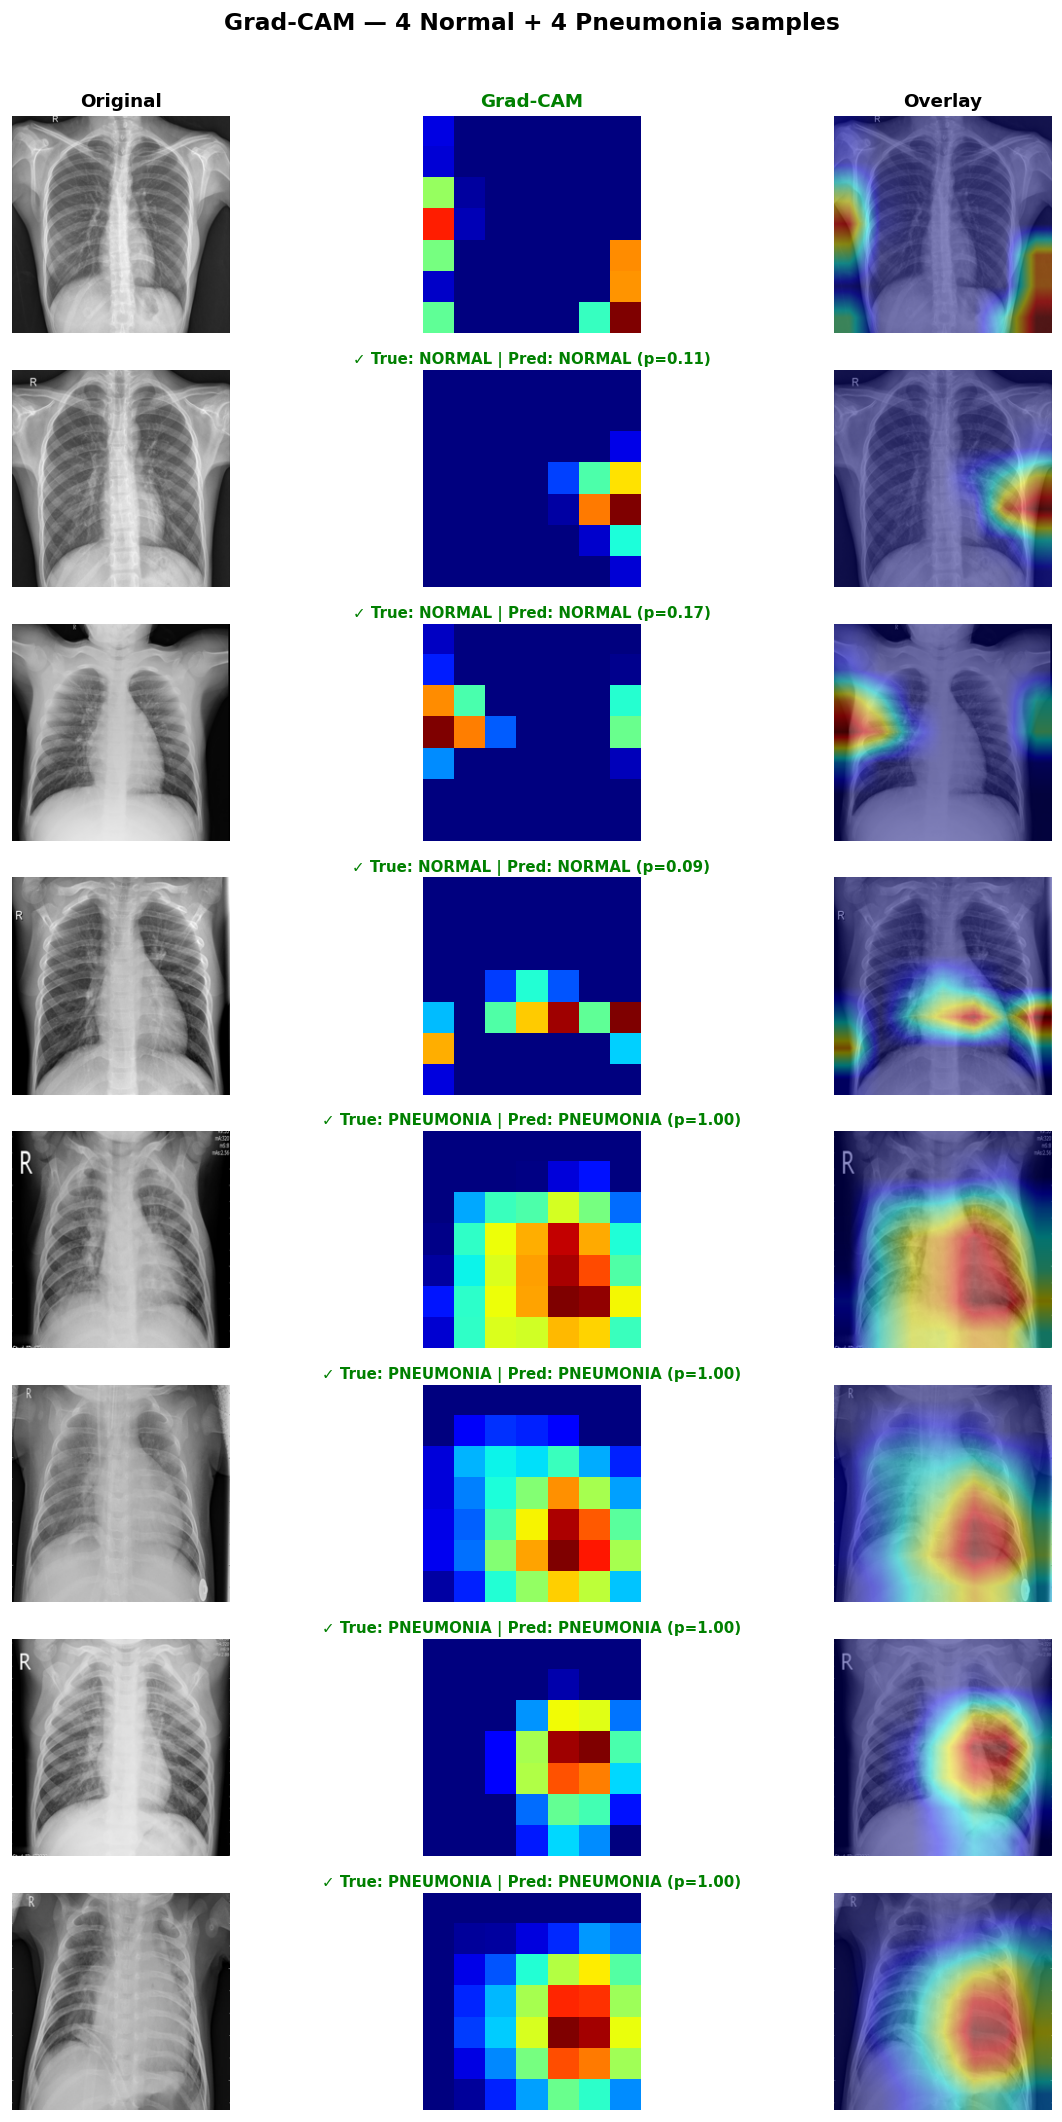

In [7]:
np.random.seed(42)

def sample_class(data_dir, label_name, n=4):
    folder = os.path.join(data_dir, label_name)
    files = [f for f in os.listdir(folder)
             if f.endswith(('.jpeg', '.jpg', '.png'))]
    chosen = np.random.choice(files, n, replace=False)
    return [os.path.join(folder, f) for f in chosen]

normal_samples = sample_class('/content/images/chest_xray/test', 'NORMAL')
pneumo_samples = sample_class('/content/images/chest_xray/test', 'PNEUMONIA')

all_samples = [(p, 'NORMAL') for p in normal_samples] + \
              [(p, 'PNEUMONIA') for p in pneumo_samples]

fig, axes = plt.subplots(8, 3, figsize=(12, 18))

plt.subplots_adjust(hspace=0.25, wspace=0.05)

for row_i, (path, true_lbl) in enumerate(all_samples):
    img_pil, tensor = load_image(path)
    cam, prob = gradcam.generate(tensor)
    overlay = overlay_heatmap(img_pil, cam)

    pred = "PNEUMONIA" if prob >= 0.5 else "NORMAL"
    correct = pred == true_lbl
    colour = 'green' if correct else 'red'
    symbol = '✓' if correct else '✗'

    axes[row_i, 0].imshow(img_pil, cmap='gray')
    axes[row_i, 0].axis('off')

    axes[row_i, 1].imshow(cam, cmap='jet')
    axes[row_i, 1].axis('off')

    axes[row_i, 2].imshow(overlay)
    axes[row_i, 2].axis('off')

    axes[row_i, 1].set_title(
        f'{symbol} True: {true_lbl} | Pred: {pred} (p={prob:.2f})',
        fontsize=9,
        color=colour,
        fontweight='bold',
        pad=4
    )

# Column titles
axes[0, 0].set_title('Original', fontweight='bold', fontsize=11)
axes[0, 1].set_title('Grad-CAM', fontweight='bold', fontsize=11)
axes[0, 2].set_title('Overlay', fontweight='bold', fontsize=11)

fig.suptitle(
    'Grad-CAM — 4 Normal + 4 Pneumonia samples',
    fontsize=14,
    fontweight='bold',
    y=0.98
)

plt.tight_layout(rect=[0, 0, 1, 0.97])

plt.savefig(
    '/content/drive/MyDrive/medical-xai/gradcam_batch.png',
    dpi=150,
    bbox_inches='tight',
    pad_inches=0.02
)

plt.show()

## Clinical Interpretation
A clinically credible Grad-CAM should highlight bilateral/unilateral opacities or consolidation regions in the lung fields for pneumonia cases, and diffuse low-activation or central regions for normal cases. If heatmaps cluster on lung periphery or non-anatomical regions, this signals a potential spurious correlation worth flagging in the final report.